<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/scrna/04_kumeleme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kümeleme: Leiden

Bu defterde hücreleri kümelere ayırıyoruz. Kural baştan: kümeleme UMAP resmi üzerinde değil, önceki rehberde kurduğumuz komşuluk grafiği üzerinde yapılır; UMAP yalnız sonucu göstermeye yarar. Algoritma olarak alanın standardı Leiden'ı kullanacağız ve aynı veriye iki farklı çözünürlükle bakacağız.

In [1]:
%pip install -q scanpy leidenalg igraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source o

## 1. Başlangıç durumu

Önceki rehberlerin tarifi tek hücrede: indir, normalize et, log al, bayrakla, raw'a kopyala, daralt, ölçekle, PCA, komşuluk grafiği. Ayrıntılar 2.2 ve 2.3'te.

In [2]:
import warnings; warnings.filterwarnings('ignore')
import urllib.request
import scanpy as sc
import numpy as np

urllib.request.urlretrieve('https://zenodo.org/records/22655336/files/pbmc3k_ders.h5ad?download=1', 'pbmc3k_ders.h5ad')
a = sc.read_h5ad('pbmc3k_ders.h5ad')
a.layers['sayim'] = a.X.copy()
sc.pp.normalize_total(a, target_sum=1e4)
sc.pp.log1p(a)
sc.pp.highly_variable_genes(a, flavor='seurat', min_mean=0.0125, max_mean=3, min_disp=0.5)
a.raw = a
a = a[:, a.var.highly_variable].copy()
sc.pp.scale(a, max_value=10)
sc.tl.pca(a, svd_solver='arpack', n_comps=50)
sc.pp.neighbors(a, n_neighbors=15, n_pcs=10)
print('hazır:', a.shape)

hazır: (2694, 1860)


## 2. Leiden

`sc.tl.leiden(a, resolution=..., key_added=...)` bir topluluk bulma algoritmasıdır: komşuluk grafiğini, içinde bağlantıların sık, gruplar arasında seyrek olduğu parçalara böler. İki parametresini kullanıyoruz:

- `resolution`: bölünme inceliğini kontrol eden düğme. Büyük değer daha çok ve daha küçük küme üretir, küçük değer daha az ve daha iri küme. Doğru bir değeri yoktur; veri ve soruya göre seçilir.
- `key_added`: sonucun `a.obs` tablosuna hangi sütun adıyla yazılacağı. Sonuç kategorik bir sütundur: her hücreye bir küme numarası.

Aynı grafiğe iki çözünürlükle bakıyoruz; `value_counts()` her kümedeki hücre sayısını verir.

In [3]:
sc.tl.leiden(a, resolution=1.0, key_added='leiden_1')
sc.tl.leiden(a, resolution=0.5, key_added='leiden_05')

print('resolution=1.0 küme sayısı:', a.obs.leiden_1.nunique())
print(a.obs.leiden_1.value_counts().sort_index())
print()
print('resolution=0.5 küme sayısı:', a.obs.leiden_05.nunique())
print(a.obs.leiden_05.value_counts().sort_index())

resolution=1.0 küme sayısı: 13
leiden_1
0     433
1     388
2     348
3     330
4     302
5     234
6     171
7     148
8     139
9     114
10     41
11     33
12     13
Name: count, dtype: int64

resolution=0.5 küme sayısı: 9
leiden_05
0    701
1    489
2    426
3    348
4    311
5    223
6    147
7     36
8     13
Name: count, dtype: int64


## 3. İki haritayı yan yana görmek

İki çözünürlük, aynı verinin iki meşru bölümlemesidir; hangisinin "doğru" olduğuna bu aşamada karar verilemez. Karar bir sonraki rehberde işaretçi genlerle verilecek: iki ayrı kümenin işaretçileri birbirinden ayrışmıyorsa çözünürlük fazladır, tek bir kümenin içinde iki farklı kimlik saklanıyorsa azdır. UMAP burada yalnız gösterim aracı: `color` parametresine küme sütunlarını veriyoruz.

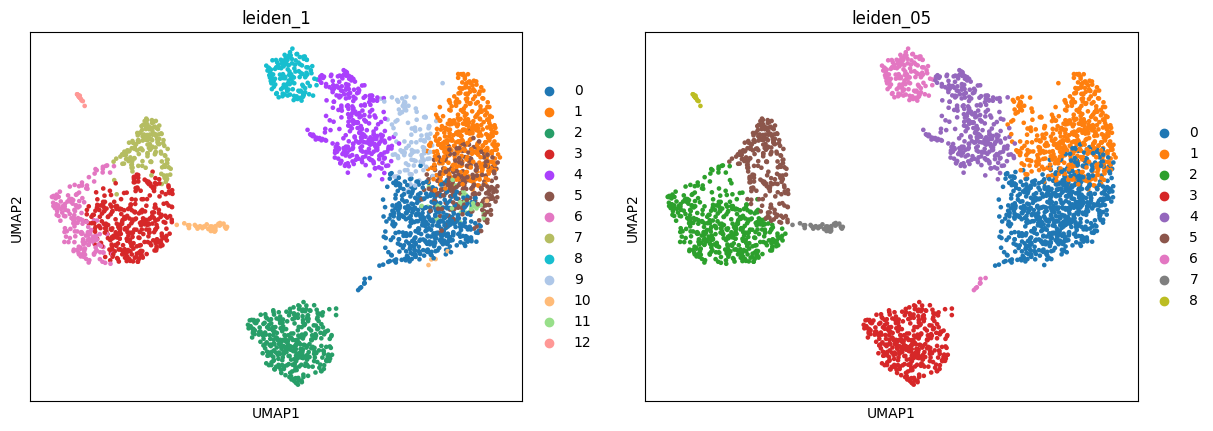

In [4]:
sc.tl.umap(a)
sc.pl.umap(a, color=['leiden_1', 'leiden_05'])

## Kendin dene

Üç görev. Birincisi: iki çözünürlükteki küme sayılarını ve küme boyu tablolarını not edin. İkincisi: önceki rehberde UMAP'a bakarak göz kararı saydığınız grup sayısını hatırlayın ve tek cümle yazın — gözünüz hangi çözünürlüğe daha yakın saymış? Üçüncüsü: en küçük kümenin kaç hücre olduğunu yazın ve tek cümleyle cevaplayın: bu kadar küçük bir grubun gerçek bir hücre tipi mi yoksa gürültü mü olduğunu ne belirler? Cevabınız bir sonraki rehberin konusunu kurmuş olacak.